# N2 · 把网整理成领域地图 (Map a Subfield)

> 配套 9.2-L3/L4 · **真实科研动作**: 把 N1 的引用网整理成 **taxonomy (流派) + timeline (演进线)**,
> 出一张演进时间线图, 落成 markdown 领域地图 —— 你两周摸领域的核心交付物。

In [1]:
import sys
from pathlib import Path
import pandas as pd
SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import snowball as sb
import field_map as fm
net = sb.load_sample_net()
papers = fm.papers_from_net(net)
print(f"载入 {len(papers)} 篇论文")

载入 12 篇论文


## 1. taxonomy: 按流派 (方法族) 分组

In [2]:
tax = fm.taxonomy(papers)
for fam, ps in tax.items():
    names = ", ".join(f"{p['name'].split(' (')[0]}({p['year']})" for p in ps)
    print(f"流派【{fam}】: {names}")

流派【理论基础】: Bradley-Terry 偏好模型(1952)
流派【RL 基础】: PPO(2017)
流派【RLHF 早期】: Learning to summarize from HF(2020)
流派【RLHF 经典】: InstructGPT(2022)
流派【直接偏好优化】: DPO(2023), IPO(2023), KTO(2024), ORPO(2024), SimPO(2024)
流派【鲁棒性】: Robust-DPO(2024)
流派【在线化】: Iterative/Online DPO(2024)
流派【推理 RL】: DeepSeek-R1(2025)


## 2. timeline: 按年份看演进 (哪年冒出哪些工作)

In [3]:
tl = fm.timeline(papers)
for year, ps in tl.items():
    print(f"{year}: " + ", ".join(p['name'].split(' (')[0] for p in ps))

1952: Bradley-Terry 偏好模型
2017: PPO
2020: Learning to summarize from HF
2022: InstructGPT
2023: DPO, IPO
2024: KTO, ORPO, SimPO, Robust-DPO, Iterative/Online DPO
2025: DeepSeek-R1


## 3. 演进时间线图 (x=年份, y=流派, 点大小=被引数)

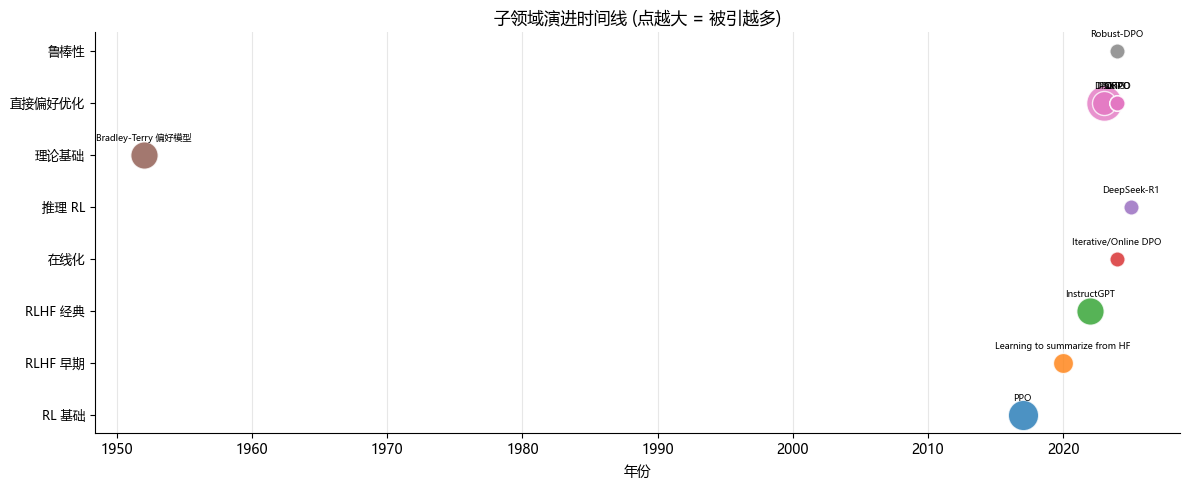

In [4]:
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus'] = False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try:
        matplotlib.rcParams['font.sans-serif'] = [f]; break
    except Exception:
        pass
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 5))
fm.plot_timeline(papers, ax=ax)
plt.tight_layout()
plt.show()

## 4. 生成 markdown 领域地图 (可直接进你的第二大脑 / mini-survey)

In [5]:
mp = fm.to_markdown_map(papers, "偏好优化 (Preference Optimization) 领域地图")
out = Path.cwd() / "_map_output"
out.mkdir(exist_ok=True)
(out / "subfield-map.md").write_text(mp, encoding="utf-8")
print(mp)

# 偏好优化 (Preference Optimization) 领域地图

> 共 12 篇, 8 个流派. ★ = 该领域奠基作 (被引最多).

## 流派: 直接偏好优化
- **DPO** (2023) — 被引 6 ★
- **IPO** (2023) — 被引 2
- **KTO** (2024) — 被引 0
- **ORPO** (2024) — 被引 0
- **SimPO (reference-free)** (2024) — 被引 0

## 流派: RL 基础
- **PPO** (2017) — 被引 4

## 流派: 理论基础
- **Bradley-Terry 偏好模型** (1952) — 被引 3

## 流派: RLHF 经典
- **InstructGPT (RLHF)** (2022) — 被引 3

## 流派: RLHF 早期
- **Learning to summarize from HF** (2020) — 被引 1

## 流派: 鲁棒性
- **Robust-DPO (噪声偏好)** (2024) — 被引 0

## 流派: 在线化
- **Iterative/Online DPO** (2024) — 被引 0

## 流派: 推理 RL
- **DeepSeek-R1 (RL for reasoning)** (2025) — 被引 0

## 我的位置 (填)
- 我的复现/方向落在哪个流派: ____
- 我最该补读的奠基作: ____
- 我看到的前线/争论 (→ 9.3 找 gap): ____


## 5. 反思 + 交棒 9.3

你现在手里有: 引用网 (N1) + 中心度排序 + taxonomy + timeline + 一张演进图 + markdown 地图。
这就是一份 mini-survey 的全部素材。

**最后一步是人做的, 不是工具做的** (这正是研究的核心):
1. 把 timeline 从「年份列表」改写成「**痛点→解法→新痛点**的因果链」(L3 §2)。
   例: RLHF(重) → DPO(隐式reward,轻) → SimPO(连reference都去掉) / Robust-DPO(攻噪声) → 在线化。
2. 在演进线**末端**找前线: 多篇共有的 limitation (如「偏好噪声」「多轮」) 就是你的 gap 富矿。
3. 带着 2-3 个洞去 **9.3 critical-reading-gap**, 用 6 类 gap 雷达逐个验证, 起 gap 卡。

> 工具把机械的整理自动化了, 但「读出因果链、嗅出前线」只能你来 —— 那是研究者真正的手艺。
> 这也是为什么这个 notebook 的终点不是一张图, 而是「带着 3 个洞走向 9.3」。